This notebook was forked from the work of

(c) [Julius Hense](https://github.com/hense96) & [Mina Jamshidi](https://github.com/minajamshidi) @ TU Berlin, 2024

(c) This notebook is an asset of xMIL: https://github.com/tubml-pathology/xMIL, from which the present repository is forked

Please note the license and citation instructions as described in the above repository.

---

# Pipeline for computing heatmaps and visualizing them

In this notebook, we demonstrate how to compute the explanation scores of a given slide and visualize the heatmap. At the end of the pipeline, you can generate overlay of the heatmap for potential use in softwares like QuPath.

Please note that in this notebook we explain the target class. please modify the respective parts (with corresponding comments in the code) in case you wanna change the explained class. 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")

In [ ]:
import os
import json
import ast

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import h5py

import openslide
import PIL

from training.callback import Callback
from models.model_factory import ModelFactory, xModelFactory
from datasets import H5Dataset, bag_collate_fn

from visualization.slideshow import plot_PIL
from visualization.utils import clean_outliers_fliers

In [ ]:
# Set deterministic behavior
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = 'cpu'

## 1. Select and load a model of interest

In [ ]:
# === SPECIFY === #

model_dir = '../trained_models'  # or specify your model directory directly here 

In [ ]:
path_to_args = 'path/to/args.json'

with open(path_to_args) as f:
    args = json.load(f)
args['path_checkpoints'] = path_to_args

In [256]:
# define callback, model, classifier, xmodel
sel_checkpoint = 'best'

callback = Callback(
        schedule_lr=args['schedule_lr'], checkpoint_epoch=1, path_checkpoints=args['path_checkpoints'],
        early_stop=args['early_stopping'], device=device)
model, classifier = ModelFactory.build(args, device)
model = callback.load_checkpoint(model, checkpoint=sel_checkpoint)

## 2. Visualizing explanation heatmaps

### 2.1. Read the pre-computed explanation scores of a desired slide

In [ ]:
df = pd.read_csv('path/to/csv')
feats_path = f'path/to/features'
df_split = pd.read_csv('path/to/split.csv')
slide_name = 'your_slide'
val_set = df_split['val'].to_list()
df.loc[df['slide_id'].isin(val_set), 'fold_0'] = 'val'
df = df[df['slide_id'] == slide_name]

In [ ]:
if args['aggregation_model'] == 'transmil':
    collate_fn = None
else:
    collate_fn = bag_collate_fn

test_loader = DataLoader(H5Dataset(feats_path, df, "test"), batch_size=1, shuffle=True, worker_init_fn=lambda _: np.random.seed(SEED), collate_fn=collate_fn)

In [ ]:
data_loader = [loader for loader in [test_loader] if loader is not None][0]
data_loader_list = list(data_loader)

In [ ]:
# ==== find the index of the batch a desired slide if the data loader object ==== 

sel_idx = [i for i, batch in enumerate(data_loader_list) if batch['sample_ids']['slide_id'][0] == slide_name][0]

# === or if you know the index of the batch ==== 
#sel_idx = 6  # *** SPECIFY: the desired batch index in the data_loader

print(f'selected index: {sel_idx}')

batch = data_loader_list[sel_idx]
patches_this_slide = batch['patch_ids']
patch_coords = batch['patch_coords']

batch

In [ ]:
# compute prediction information

preds, label, _, slide_info = classifier.validation_step(batch)

label = label.item()
#source_idx = slide_info['source_id'][0]
slide_name = slide_info['slide_id'][0]

exlained_class = label # we want to explain the target class, change this if you wish to change it
pred_score = preds[0, exlained_class].item()  

print(slide_name, label, pred_score)

In [ ]:
xmodel_args = {'explained_class': exlained_class} # change this if you wish to explain a specific class
xmodel = xModelFactory.build(model, xmodel_args)

### 2.2. Plotting the heatmap

#### Visualize the slide and its annotation

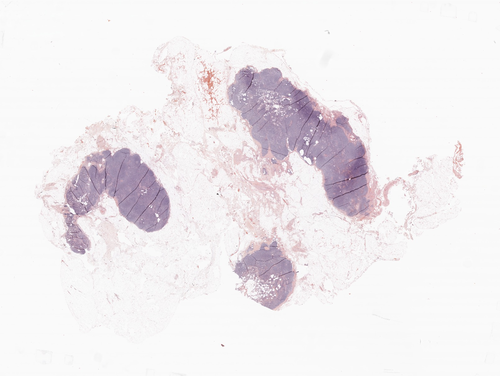

In [ ]:
from openslide import OpenSlide

path_slide = 'path/to/slide.svs'

slide = OpenSlide(path_slide)
slide.get_thumbnail((500,500))

#### Compute and visualize the heatmap of the desired explanation method

In [275]:
# =========== SPECIFY =============
sel_explanation = 'lrp'  # ***SPECIFY: could be perturbation_keep, lrp, gi, grad2

if sel_explanation == 'perturbation_keep':
    xmodel.explained_rel = 'softmax'
else:
    xmodel.explained_rel = 'logit'

In [ ]:
# compute explanation scores

annotation = None

patch_ids = batch['patch_ids'].numpy()
patch_ids = patch_ids[0] if len(patch_ids.shape) > 1 else patch_ids

patch_scores = xmodel.get_heatmap(batch, sel_explanation, verbose=False)
patch_scores = patch_scores[0] if len(patch_scores.shape) > 1 else patch_scores

if annotation is not None:
    patch_labels = patches_this_slide.copy().set_index('patch_id').loc[patch_ids]
    patch_labels = patch_labels['annotation_classes'].apply(lambda x: pd.Series(ast.literal_eval(x)))
    patch_labels = np.asarray((patch_labels['2'] > 0.0).astype(int))
else:
    patch_labels = None
    
patch_scores_plot, _ = clean_outliers_fliers(patch_scores)

In [277]:
import math


def build_overlay(size, patch_ids, patch_coords, patch_size, slide_dim, overlay_rgb, background='black'):
    """
    (c) modified from https://github.com/hense96/patho-preprocessing
    Args:
        patches: the dataframe containing the metadata of the patches of this slide
        size: the desired size of the overlay
        patch_ids: the patch IDs for which we want to build the overlay and have the overlay RGB values
        slide_dim: slide.dimensions if slide is the openslide object
        overlay_rgb: [n-patch x 3] The RGB values of the patches in patch_ids
        background: background color for the overlay ['black', 'white']

    Returns: The PIL image of the overlay

    """
    if background == 'black':
        overlay_image = np.zeros((size[0], size[1], 3))
    elif background == 'white':
        overlay_image = np.ones((size[0], size[1], 3))
    else:
        raise ValueError(f"Unsupported background color for overlay: {background}")
    for i, id_ in enumerate(patch_ids):
        #this_patch = patches[patches['patch_id'] == id_]
        #x_coord, y_coord = ast.literal_eval(this_patch['position_abs'].item())
        #patch_size = this_patch['patch_size_abs']
        x_coord, y_coord = patch_coords[i, :] 
        ds_x_coord = int(x_coord * (size[0] / slide_dim[0]))
        ds_y_coord = int(y_coord * (size[1] / slide_dim[1]))
        ds_patch_size_x = int(math.ceil(patch_size * (size[0] / slide_dim[0])))
        ds_patch_size_y = int(math.ceil(patch_size * (size[1] / slide_dim[1])))
        overlay_image[ds_x_coord:(ds_x_coord + ds_patch_size_x), ds_y_coord:(ds_y_coord + ds_patch_size_y), :] = \
            overlay_rgb[i, :]
    img = np.uint8(np.transpose(overlay_image, (1, 0, 2)) * 255)
    return Image.fromarray(img)

In [278]:
from visualization.utils import convert2rgb, plot_colorbar
from PIL import Image
import textwrap

def heatmap_PIL(size, patch_ids, patch_coords, patch_size, slide_dim, score_values, cmap_name='coolwarm', background='black',
                zero_centered=True):
    """
    builds the PIL image of the attention values.
    Args:
        patches: the dataframe containing the metadata of the patches of this slide
        size: the desired size of the heatmap
        patch_ids: the patch IDs for which we want to build the overlay and have the overlay RGB values
        slide_dim: slide.dimensions if slide is the openslide object
        score_values: The attention values to be converted to a PIL image
        cmap_name: colormap
        background: background color for the overlay ['black', 'white']
        zero_centered: if True, the heatmap colors will be centered at score 0.0

    Returns: The PIL image of the attention image and the RGB values corresponding to the attention values

    """
    scores_rgb = convert2rgb(score_values, cmap_name=cmap_name, zero_centered=zero_centered)
    img = build_overlay(size, patch_ids, patch_coords, patch_size, slide_dim, scores_rgb, background)
    return img, scores_rgb

In [279]:
patch_coords = patch_coords.squeeze()

In [281]:
def slide_heatmap_thumbnail(slide, patch_ids, patch_coords, patch_size, patch_scores, slide_name=None, label=None, target_names=None,
                            pred_score=None, annotation=None, side_by_side=True, size=(2048, 2048),
                            cmap_name='coolwarm', background='black', zero_centered=True, title_wrap_width=40):
    """"
    Plots a thumbnail of the original slide with the heatmap.

    :param slide: openslide Slide object
    :param patches: dataframe containing the metadata of the patches of this slide
    :param patch_ids: (list-like) the patch IDs for which we want to build a heatmap, corresponding to the patch scores
    :param patch_scores: (list-like) the patch scores to be visualized in the heatmap
    :param slide_name: (str) ID of the slide (optional)
    :param label: (int/float/str or list of int/float/str) label(s) of the slide (optional)
    :param target_names: (list of str) names of the targets (optional)
    :param pred_score: (float of list of floats) prediction score(s) assigned to the slide (optional)
    :param annotation: openslide object of the annotation to be added to the slide as an overlay (optional)
    :param side_by_side: (bool) if True, slide and heatmap are plotted side-by-side; if False, they are overlaid into
        a single plot
    :param size: (int, int) maximum size of the thumbnails
    :param cmap_name: (str) matplotlib colormap for the heatmap
    :param background: (str) background color for the heatmap ['black', 'white']
    :param zero_centered: (bool) if True, the heatmap colors will be centered at score 0.0
    :return: matplotlib figure
    """
    # Create thumbnails of available data
    slide_thumbnail = slide.get_thumbnail(size)
    heatmap, _ = heatmap_PIL(
        slide_thumbnail.size, patch_ids, patch_coords, patch_size, slide.dimensions, patch_scores,
        cmap_name=cmap_name, background=background, zero_centered=zero_centered)
    if annotation is not None:
        slide_thumbnail = overlay(slide_thumbnail, annotation.get_thumbnail(slide_thumbnail.size), 40)

    # Plot the thumbnails
    fig = plt.figure()
    gs = fig.add_gridspec(2, 2, height_ratios=[32, 1])
    if slide_name is not None:
        fig.suptitle(slide_name, fontsize=12)

    # if labels or prediction scores are lists of values (e.g., for multi-target models), convert them to strings.
    # if target_names are given, add the target names to the labels and prediction scores
    if label is not None and isinstance(label, list):
        if target_names is not None and isinstance(target_names, list) and len(target_names) == len(label):
            label = ', '.join([l_name + ': ' + str(l) for l, l_name in zip(label, target_names)])
        else:
            label = ', '.join([str(l) for l in label])
    if pred_score is not None and isinstance(pred_score, list):
        if target_names is not None and isinstance(target_names, list) and len(target_names) == len(pred_score):
            pred_score = ', '.join([l_name + f": {p:.4f}" for p, l_name in zip(pred_score, target_names)])
        else:
            pred_score = ', '.join([f"{p:.4f}" for p in pred_score])

    if side_by_side:
        ax_left = fig.add_subplot(gs[0, 0])
        ax_right = fig.add_subplot(gs[0, 1])
        plot_PIL(ax_left, slide_thumbnail)
        plot_PIL(ax_right, heatmap)
        if label is not None:
            # wrap the label text to avoid overlapping with the slide thumbnail
            label = textwrap.fill(label, width=title_wrap_width, break_long_words=True)
            ax_left.set_title(f"Label(s): {label}", fontsize=8)
        if pred_score is not None:
            # wrap the prediction text to avoid overlapping with the slide thumbnail
            pred_score = textwrap.fill(pred_score, width=title_wrap_width, break_long_words=True)
            ax_right.set_title(f"Prediction(s): {pred_score}", fontsize=8)
    else:
        slide_thumbnail = overlay(slide_thumbnail, heatmap, 130)
        ax_top = fig.add_subplot(gs[0, :])
        plot_PIL(ax_top, slide_thumbnail)
        title_text = ''
        if label is not None:
            title_text += f"  Label(s): {label}  "
        if pred_score is not None:
            title_text += f"  Prediction(s): {pred_score}  "
        if len(title_text) > 0:
            # wrap the title text to avoid overlapping
            title_text = textwrap.fill(title_text, width=title_wrap_width, break_long_words=True)
            ax_top.set_title(title_text, fontsize=8)

    # Create a color bar for the heatmap beneath the thumbnails
    ax_bottom = fig.add_subplot(gs[1, :])
    plot_colorbar(ax_bottom, patch_scores, cmap=cmap_name, ori='horizontal', zero_centered=zero_centered)

    fig.tight_layout()

    return fig

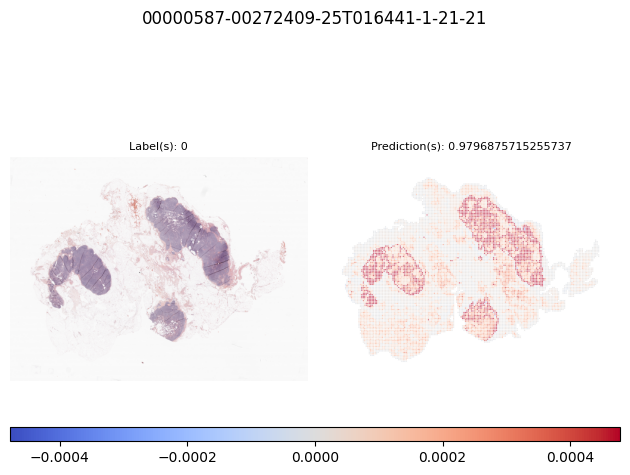

In [283]:
# Visualize patch scores in heatmap
side_by_side = True
show_annotation = True
zero_centered = xmodel.get_heatmap_zero_centered(sel_explanation)

cmap_name = 'coolwarm' if zero_centered else 'Reds'
patch_size = 256

_ = slide_heatmap_thumbnail(
    slide, patch_ids, patch_coords, patch_size, patch_scores_plot,
    slide_name=slide_name, label=str(label), pred_score=str(pred_score),
    annotation=(annotation if show_annotation else None), side_by_side=side_by_side,
    size=(2048, 2048), cmap_name=cmap_name, background='white', zero_centered=zero_centered)

### 2.3. Generating the overlay for QuPath

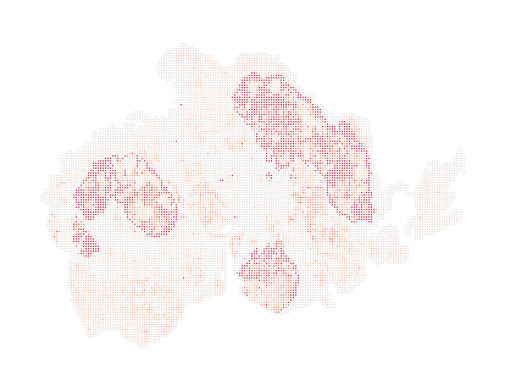

In [284]:
overlay_dims = (slide.dimensions[0] // 32, slide.dimensions[1] // 32)

with h5py.File(os.path.join(f'/data/m-056285/dial/trident_data/BeMeLy/20x_256px_0px_overlap/features_{model_name}_vanilla/00000587-00272409-25T016441-1-21-21.h5'), "r") as f:
    orig_coords = torch.from_numpy(f["coords"][:])


heatmap, _ = heatmap_PIL(
    size=overlay_dims, patch_ids=patch_ids, patch_coords=patch_coords,
    patch_size=256, slide_dim=slide.dimensions, score_values=patch_scores_plot, background='white')

fig = plt.figure()
ax = fig.add_subplot(111)

plot_PIL(ax, heatmap, cmap=cmap_name)

# heatmap.save(os.path.join(overlays_dir, f"{slide_name}_{sel_explanation}.png"), "PNG")


------